## 0. Setup

In [1]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [2]:
# general
from pathlib import Path

import geopandas as gpd

# for plotting and coloring
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from tqdm.notebook import tqdm

gpd.options.io_engine = "pyogrio"

In [3]:
from gridsample.utils import create_gmap_links, save_shapefiles
# from gridsample.mapping import create_interactive_map

In [4]:
from utils import (
    download_VIDA_rooftops_data_by_s2,
    generate_colormap,
    get_matched_rooftop_centroids_from_s2_file,
    get_s2_cell_ids,
    s2_cell_ids_to_shapes_gdf,
)

In [5]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data_ifa"
RAW_DATA_DIR = DATA_DIR / "01. Raw Data"
PROCESSED_DATA_DIR = DATA_DIR / "02. Processed Data"
OUTPUT_DATA_DIR = DATA_DIR / "03. Output Data"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

Need to also symlink the VIDA rooftop data folder inside Raw Data. MacOS:

    ln -s "/Users/amiremami/IDinsight Dropbox/Amir Emami/VIDA S2 Rooftop Data" "VIDA S2 Rooftop Data"

## 1. Load MapSolve boundaries

In [6]:
# get all filepaths that end in `gpkg` inside the RAW_DATA_DIR / 0.1. MapSolve Boundaries
boundaries_dir = RAW_DATA_DIR / "Admin Boundaries" / "shrug-pc11subdist-poly-shp/subdistrict.shp"
gdf = gpd.read_file(boundaries_dir).to_crs(4326)

## 2. Load sampled subdistricts data

In [7]:
# load the merged wards data
sample_df = pd.read_csv(
    RAW_DATA_DIR
    / "Admin Boundaries"
    / "UP_Bihar_Subdistricts.csv"
)

In [8]:
sample_df

,State,District,Subdistt,TOT_P,high_density
0,10,203,1014,249102.0,0
1,10,203,1015,208169.0,0
2,10,203,1016,190744.0,0
3,10,203,1017,377842.0,0
4,10,203,1019,398000.0,0
...,...,...,...,...,...
307,9,199,1002,NaN,0
308,9,199,1003,NaN,0
309,9,200,1004,NaN,0
310,9,200,1005,NaN,0


### 2.1 Rename and clean both datasets

In [9]:
gdf.rename(columns={
    "pc11_s_id": "state",
    "pc11_d_id": "district",
    "pc11_sd_id": "subdistrict",
    "sd_name": "subdistrict_name"
    }, inplace=True)

In [10]:
sample_df.rename(
    columns={
        "State": "state",
        "District": "district",
        "Subdistt": "subdistrict",
        "TOT_P": "total_population",
    },
    inplace=True,
)

In [11]:
# make relevant codes into floats for both datasets
code_columns = [
    "state",
    "district",
    "subdistrict",
]
for col in code_columns:
    sample_df[col] = sample_df[col].astype(int)
    gdf[col] = gdf[col].astype(int)

## 3. Filter boundaries to sampled areas

In [12]:
# filter based on state/district/subdistrict codes
filtered_gdf = gdf.merge(
    sample_df,
    on=["state", "district", "subdistrict"],
    how="inner",
)

In [13]:
filtered_gdf["state_name"] = filtered_gdf["state"].map(
    {
        10: "Bihar",
        9: "UP",
    }
)

In [14]:
filtered_gdf

,state,district,subdistrict,subdistrict_name,geometry,total_population,high_density,state_name
0,9,135,717,Thakurdwara,"POLYGON ((78.76152 29.26113, 78.76414 29.26109...",NaN,0,UP
1,9,135,718,Kanth,"MULTIPOLYGON (((78.72406 29.09949, 78.72378 29...",NaN,0,UP
2,9,135,719,Moradabad,"POLYGON ((78.97374 29.15127, 78.97444 29.15120...",NaN,1,UP
3,9,135,720,Bilari,"POLYGON ((78.70604 28.79828, 78.70677 28.79745...",NaN,1,UP
4,9,135,721,Sambhal,"POLYGON ((78.62103 28.80418, 78.62298 28.80306...",NaN,1,UP
...,...,...,...,...,...,...,...,...
307,10,238,1532,Khaira,"POLYGON ((86.18143 24.90653, 86.18191 24.90650...",235761.0,0,Bihar
308,10,238,1534,Chakai,"POLYGON ((86.49264 24.70085, 86.49362 24.70061...",235188.0,0,Bihar
309,10,239,1535,Ratni Faridpur,"POLYGON ((84.89004 25.25375, 84.89035 25.25374...",146586.0,0,Bihar
310,10,239,1540,Makhdumpur,"POLYGON ((85.07797 25.15016, 85.07815 25.14854...",260154.0,0,Bihar


In [15]:
set(filtered_gdf["subdistrict"].unique()).difference(set(sample_df["subdistrict"].unique()))

set()

In [16]:
set(sample_df["subdistrict"].unique()).difference(set(filtered_gdf["subdistrict"].unique()))

set()

<Axes: >

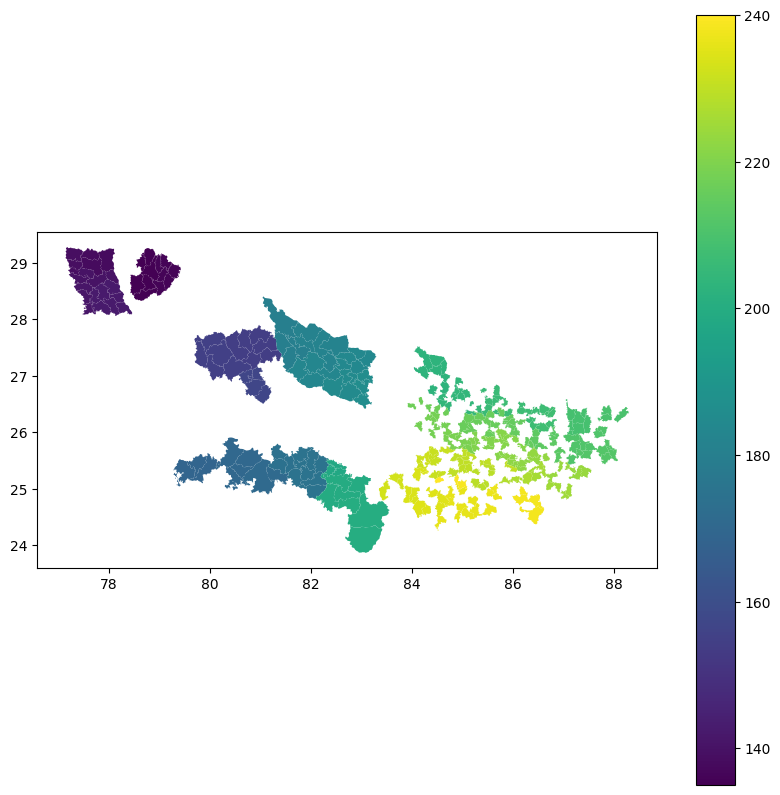

In [17]:
filtered_gdf.plot(column="district", figsize=(10, 10), legend=True)

## 5. Download rooftops

#### Identify S2 cell IDs

Shapes with spillover after round 1: 8


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:126: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name="geometry")


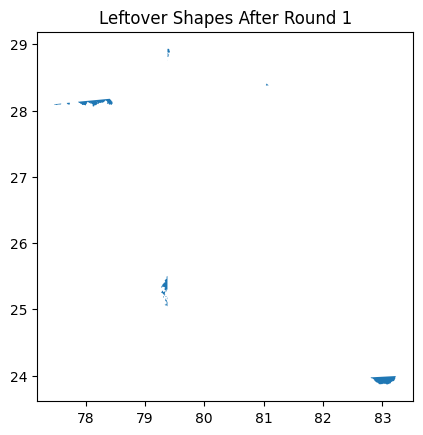

Shapes with spillover after round 2: 2


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:142: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


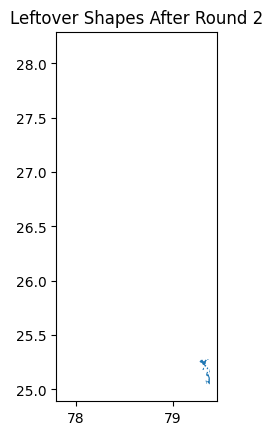

Shapes with spillover after round 3: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:142: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


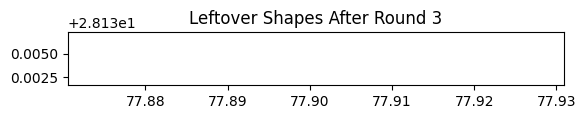

28

In [18]:
s2_cell_ids = get_s2_cell_ids(filtered_gdf)
len(s2_cell_ids)

#### Check if identified cells cover all areas of interest

In [19]:
s2_cells_gdf = s2_cell_ids_to_shapes_gdf(s2_cell_ids)

In [20]:
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = filtered_gdf.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")

0.0 square degrees area not covered by an S2 cell


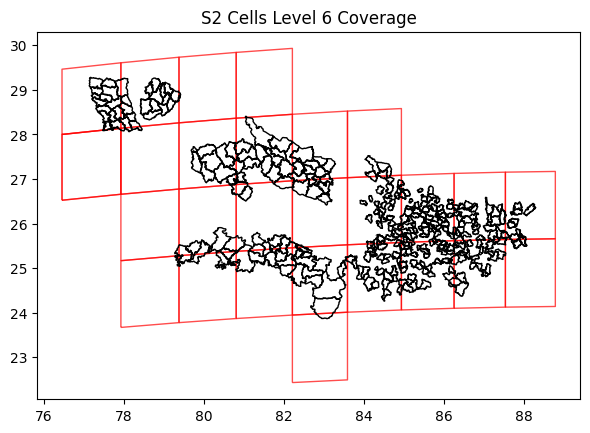

In [21]:
# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
filtered_gdf.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()

In [22]:
s2_cells_gdf_w_state = (
    s2_cells_gdf.sjoin(
        filtered_gdf[["state_name", "geometry"]], how="inner", predicate="intersects"
    )
    .drop(columns="index_right")
    .drop_duplicates()
)

In [23]:
# note: this will have duplicate s2 cell rows with different states if the s2 cell overlaps multiple states
# this is expected and is required for the next steps logic to work correctly
s2_cells_gdf_w_state

,s2_cell_id,geometry,state_name
0,4110379084905709568,"POLYGON ((77.92817 28.13705, 79.38034 28.25840...",UP
22,4140215432437039104,"POLYGON ((77.92817 26.65639, 79.38034 26.77340...",UP
1,4110942034859130880,"POLYGON ((76.45631 27.99812, 77.92817 28.13705...",UP
21,4139652482483617792,"POLYGON ((76.45631 26.52245, 77.92817 26.65639...",UP
20,4152600331412307968,"POLYGON ((79.38034 28.25840, 80.81009 28.36264...",UP
2,4152037381458886656,"POLYGON ((79.38034 26.77340, 80.81009 26.87394...",UP
3,4150348531598622720,"POLYGON ((80.81009 26.87394, 82.21486 26.95856...",UP
4,4150911481552044032,"POLYGON ((80.81009 25.37506, 82.21486 25.45633...",UP
5,4151474431505465344,"POLYGON ((79.38034 25.27853, 80.81009 25.37506...",UP
8,4149785581645201408,"POLYGON ((82.21486 26.95856, 83.59226 27.02792...",UP


#### Download the S2 cells

In [24]:
download_VIDA_rooftops_data_by_s2(s2_cell_ids, "IND", RAW_DATA_DIR / "VIDA S2 Rooftop Data" / "Available")

File 4110379084905709568 already exists.
File 4110942034859130880 already exists.
File 4152037381458886656 already exists.
File 4150348531598622720 already exists.
File 4150911481552044032 already exists.
File 4151474431505465344 already exists.
File 4144156082110988288 already exists.
File 4144719032064409600 already exists.
File 4149785581645201408 already exists.
File 4148096731784937472 already exists.
File 4147533781831516160 already exists.
File 4149222631691780096 already exists.
File 4148659681738358784 already exists.
File 4173992429642317824 already exists.
File 4174555379595739136 already exists.
File 4171740629828632576 already exists.
File 4175118329549160448 already exists.
File 4177933079316267008 already exists.
File 4175681279502581760 already exists.
File 4146970831878094848 already exists.
File 4152600331412307968 already exists.
File 4139652482483617792 already exists.
File 4140215432437039104 already exists.
File 4140778382390460416 already exists.
File 41531632813

## 6. Load rooftops and match to areas

In [25]:
state_names = filtered_gdf["state_name"].sort_values().unique()

In [26]:
# for state_name in tqdm(state_names):
#     print(f"Processing state: {state_name}")

#     # Filter the s2 cells and rooftops gdf to the current state
#     s2_cell_ids = set(
#         s2_cells_gdf_w_state[s2_cells_gdf_w_state["state_name"] == state_name][
#             "s2_cell_id"
#         ]
#     )
#     print(
#         f"Number of S2 cells that overlap our shapes in {state_name}: {len(s2_cell_ids)}"
#     )
#     gdf_subset = filtered_gdf[filtered_gdf["state_name"] == state_name]

#     # Get matched rooftops for each S2 cell in the state
#     matched_rooftop_centroids_gdf_list = []
#     for s2_cell_id in tqdm(s2_cell_ids):
#         matched_rooftop_centroids_gdf = get_matched_rooftop_centroids_from_s2_file(
#             s2_file_dir=RAW_DATA_DIR / "VIDA S2 Rooftop Data" / "Available",
#             s2_cell_id=s2_cell_id,
#             boundaries_gdf=gdf_subset,
#         )
#         matched_rooftop_centroids_gdf_list.append(matched_rooftop_centroids_gdf)
#     matched_rooftop_centroids_gdf = pd.concat(
#         matched_rooftop_centroids_gdf_list, ignore_index=True
#     )
#     matched_rooftop_centroids_gdf["state_name"] = state_name

#     # Save the matched rooftops data
#     save_shapefiles(
#         matched_rooftop_centroids_gdf,
#         PROCESSED_DATA_DIR / "01. Matched Rooftop Data" / f"{state_name}",
#         "matched_rooftops",
#         ["parquet"],
#     )

In [27]:
# ax = matched_rooftop_centroids_gdf.sample(1000).plot(
#     cmap=ListedColormap(generate_colormap(len(matched_rooftop_centroids_gdf))),
# )
# gdf_subset.plot(ax=ax, color="none", edgecolor="black", linewidth=0.5)

## 7. Load matched rooftops

In [28]:
matched_rooftop_dir = PROCESSED_DATA_DIR / "01. Matched Rooftop Data"
all_filepaths = list(matched_rooftop_dir.glob("**/*.parquet"))
all_filepaths = [f for f in all_filepaths if f.is_file()]

# filter to those that have selected_states in the name
all_filepaths = [
    f for f in all_filepaths if any(state in f.parent.name for state in state_names)
]

# load all shapes into one gdf
matched_rooftops_gdf_list = []
for filepath in tqdm(all_filepaths):
    matched_rooftops_gdf_list.append(gpd.read_parquet(filepath))
matched_rooftops_gdf = gpd.GeoDataFrame(
    pd.concat(matched_rooftops_gdf_list, ignore_index=True)
).to_crs(4326)

  0%|          | 0/2 [00:00<?, ?it/s]

In [29]:
# temp
matched_rooftops_gdf["state_name"] = matched_rooftops_gdf["state"].map(
    {
        10: "Bihar",
        9: "UP",
    }
)

In [30]:
len(matched_rooftops_gdf)

48009745

In [31]:
no_rooftop_subdistrict_IDs = set(filtered_gdf[filtered_gdf["state"].isin(state_names)]["subdistrict"].unique()).difference(
    set(matched_rooftops_gdf["subdistrict"].unique())
)
no_rooftop_subdistrict_gdf = filtered_gdf[filtered_gdf["subdistrict"].isin(no_rooftop_subdistrict_IDs)]
no_rooftop_subdistrict_gdf

,state,district,subdistrict,subdistrict_name,geometry,total_population,high_density,state_name


In [33]:
if len(no_rooftop_subdistrict_gdf) > 0:
    print("Saving subdistricts with no rooftops...")
    save_shapefiles(
        no_rooftop_subdistrict_gdf,
        OUTPUT_DATA_DIR / "Sampled Subdistricts",
        "subdistricts_with_no_rooftops",
        ["csv", "kml"],
    )

## 8. Sample rooftops

In [ ]:
# Define the base number of rooftops per ward
ROOFTOPS_PER_WARD = 75

# Sample rooftops, multiplying by Ward Count for each PSU.
sampled_rooftops = matched_rooftops_gdf.groupby("subdistrict", group_keys=False).apply(
    lambda x: x.sample(
        n=min(ROOFTOPS_PER_WARD * int(x["Ward Count"].iloc[0]), x.shape[0]),
        random_state=42,
    )
)

In [ ]:
print("Length of matched_rooftops_gdf:", len(matched_rooftops_gdf))
print("Length of sampled rooftops:", len(sampled_rooftops))

In [ ]:
# Check if Ward Count is correctly influencing sample sizes
TEMP_ward_count_df = matched_rooftops_gdf[["subdistrict", "Ward Count"]].drop_duplicates()
TEMP_ward_count_df["Expected Rooftop Count"] = TEMP_ward_count_df["Ward Count"] * ROOFTOPS_PER_WARD
TEMP_sampled_counts = (
    sampled_rooftops.groupby("subdistrict").size()
).reset_index(name="Sampled Rooftop Count")

# Merge the two dataframes
TEMP_check_df = TEMP_ward_count_df.merge(TEMP_sampled_counts, on="subdistrict")
TEMP_check_df["Rooftop Count Difference"] = (
    TEMP_check_df["Expected Rooftop Count"] - TEMP_check_df["Sampled Rooftop Count"]
)
TEMP_check_df[TEMP_check_df["Rooftop Count Difference"] != 0]

In [ ]:
sampled_rooftops.plot(
    figsize=(8, 8),
    column="state",
    cmap="tab20",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
)

### Add sample-level rooftop numbering ID columns

In [ ]:
# Rooftop number within each state
sampled_rooftops["Rooftop State ID"] = (
    sampled_rooftops.groupby("state").cumcount() + 1
)

# Rooftop number within each subdistrict
sampled_rooftops["Rooftop subdistrict Numeric"] = sampled_rooftops.groupby("subdistrict").cumcount() + 1
# add prefix of "PIN "  to the Rooftop subdistrict
sampled_rooftops["Rooftop subdistrict"] = "PIN " + sampled_rooftops["Rooftop subdistrict Numeric"].astype(
    str
)

# Rooftop unique ID
sampled_rooftops["Rooftop Unique ID"] = sampled_rooftops.apply(
    lambda row: f"STATE_{row['Rooftop State ID']}_PSU_ID_{row['subdistrict']}_ROOFTOP_{row['Rooftop subdistrict']}",
    axis=1,
)

### Add gmap link

In [ ]:
sampled_rooftops["latitude_original"] = sampled_rooftops.geometry.y
sampled_rooftops["longitude_original"] = sampled_rooftops.geometry.x
sampled_rooftops["gmap_link_original"] = create_gmap_links(
    df=sampled_rooftops,
    lat_name="latitude_original",
    lon_name="longitude_original",
)

### Select only useful columns

**Required columns:**
- PSU info
    - Unique ID across all rooftops
    - Rooftop state ID, #
    - Rooftop subdistrict, #

    - PSU Unit: Ward, TV, Subdistrict
    - PSU sample size

- geospatial info
    - google maps link
    - coordinates
    - geometry

- Admin location info
    - State code and name
    - District code and Name
    - Subdistrict code and name
    - TV code and name
    - Ward code and name

In [ ]:
chosen_cols = [
    ## IDs
    "Rooftop State ID",
    "Rooftop subdistrict",
    "Rooftop subdistrict Numeric",
    "Rooftop Unique ID",
    ## Geospatial data
    "geometry",
    "latitude_original",
    "longitude_original",
    "gmap_link_original",
    ## PSU info
    "subdistrict",
    "PSU Type",
    "Ward Count",
    ## Location info
    "State Code",
    "state",
    "State Changed",
    "District Code",
    "District Name",
    "Subdistrict Code",
    "Subdistrict Name",
    "TV Code",
    "TV Name",  # (from MapSolve)
    "Ward Code",
    "Ward/Village Name",
    "Urban/Rural",
    "PCA_ID",  # combined TVCode-WardCode
    "Ward Population",
    "Subdistrict Population",
    "State Population",
    # "Complete ID",
    ## Admin information
    "Included in Panel",
    "Ward Boundary Available with MapSolve",
    # "State Shared by MapSolve",
    "Ward Boundary Given",
    "TV Boundary Given",
    "SubDistrict Boundary Given",
    "Delivery State",
    # "UID",
    # "s2_rooftop_id",
    ## MapSolve location info
    "State Code_MapSolve",
    "state_MapSolve",
    "District Code_MapSolve",
    "District Name_MapSolve",
    "Subdistrict Code_MapSolve",
    "Subdistrict Name_MapSolve",
    "TV Code_MapSolve",
    # "TV Name",
    "Ward Code_MapSolve",
    "PCA_ID_MapSolve",
    "Total Population",
    # ## rooftop info
    # "boundary_id",
    # "bf_source",
    # "confidence",
    # "area_in_meters",
    # "s2_id",
    # "country_iso",
    # "geohash",
    # "bbox",
]

In [ ]:
sampled_rooftops_organised_gdf = sampled_rooftops[chosen_cols]

In [ ]:
sampled_rooftops_organised_gdf.rename(
    columns={
        "TV Name": "TV Name_MapSolve",
        "subdistrict": "subdistrict",
        "Total Population": "PSU Total Population_MapSolve",
    },
    inplace=True,
)

In [ ]:
# set Ward Codes of 0.0 to NaN
sampled_rooftops_organised_gdf.loc[
    sampled_rooftops_organised_gdf["Ward Code"] == 0.0, "Ward Code"
] = np.nan

In [ ]:
sampled_rooftops_organised_gdf

### Save sampled data (original rooftop pins)

In [ ]:
sampled_rooftops_organised_gdf["Subdistrict Population"] = sampled_rooftops_organised_gdf["Subdistrict Population"].astype(str)
sampled_rooftops_organised_gdf["State Population"] = sampled_rooftops_organised_gdf["State Population"].astype(str)

In [ ]:
save_shapefiles(
    sampled_rooftops_organised_gdf,
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_centroids_original",
    ["csv", "parquet"],
)

save_shapefiles(
    sampled_rooftops_organised_gdf.drop(columns=["gmap_link_original"]),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_centroids_original",
    ["kml"],
)

## 9. Snap points to road

In [ ]:
import yaml
from shapely import Point

from utils import get_nearest_points_on_road_batch, get_nearest_points_on_road_batch_parallel

In [ ]:
# load API key
with open("../secrets/api_keys.yaml", "r") as f:
    config = yaml.safe_load(f)
    api_key = config["GOOGLE_ROADS_API_KEY"]

In [ ]:
get_nearest_points_on_road_batch([Point(77.11432151622034, 28.677391409999522)], api_key)

In [ ]:
# test
get_nearest_points_on_road_batch(sampled_rooftops_organised_gdf.geometry.iloc[:5], api_key)

In [ ]:
get_nearest_points_on_road_batch_parallel(sampled_rooftops_organised_gdf.iloc[:150], api_key)

#### Snap points to road

In [ ]:
snapped_points_series = get_nearest_points_on_road_batch_parallel(
    sampled_rooftops_organised_gdf, api_key, max_workers=12
)
# took 1 second for 1,600 points (Panel)
# 30s for all 53,000 points 

In [ ]:
sampled_rooftops_snapped_gdf = sampled_rooftops_organised_gdf.copy()
sampled_rooftops_snapped_gdf["geometry_snapped"] = sampled_rooftops_snapped_gdf.index.map(snapped_points_series)

In [ ]:
# Make new Geometry Type column which has values "Original" or "Snapped to Road"
sampled_rooftops_snapped_gdf["Geometry Type"] = (
    sampled_rooftops_snapped_gdf["geometry_snapped"]
    .notna()
    .replace({True: "Snapped to Road", False: "Original"})
)
sampled_rooftops_snapped_gdf["Geometry Type"].value_counts()

#### Replace geometry to snapped one (missing filled in with original)

In [ ]:
# backup the original geometry
sampled_rooftops_snapped_gdf["geometry_original"] = sampled_rooftops_snapped_gdf[
    "geometry"
]
# replace the original geometry with the snapped geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry_snapped"
]
# drop the snapped geometry column
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf.drop(
    columns=["geometry_snapped"]
)
# fill in NaN values in the snapped geometry with the original geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry"
].fillna(sampled_rooftops_snapped_gdf["geometry_original"])

In [ ]:
sampled_rooftops_snapped_gdf["geometry"].isna().sum()

#### Update lat, lon, gmap_link

In [ ]:
sampled_rooftops_snapped_gdf["latitude"] = list(sampled_rooftops_snapped_gdf.geometry.y)
sampled_rooftops_snapped_gdf["longitude"] = list(
    sampled_rooftops_snapped_gdf.geometry.x
)
sampled_rooftops_snapped_gdf["gmap_link"] = create_gmap_links(
    df=sampled_rooftops_snapped_gdf,
    lat_name="latitude",
    lon_name="longitude",
)

#### Reorganise

In [ ]:
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf[
    [
        "Rooftop State ID",
        "Rooftop subdistrict",
        "Rooftop subdistrict Numeric",
        "Rooftop Unique ID",
        # new columns start
        "Geometry Type",
        "geometry",
        "latitude",
        "longitude",
        "gmap_link",
        # new columns end
        "geometry_original",
        "latitude_original",
        "longitude_original",
        "gmap_link_original",
        "subdistrict",
        "PSU Type",
        "Ward Count",
        "State Code",
        "state",
        "State Changed",
        "District Code",
        "District Name",
        "Subdistrict Code",
        "Subdistrict Name",
        "TV Code",
        "TV Name_MapSolve",
        "Ward Code",
        "Ward/Village Name",
        "Urban/Rural",
        "PCA_ID",
        "Ward Population",
        "Subdistrict Population",
        "State Population",
        "Included in Panel",
        "Ward Boundary Available with MapSolve",
        "Ward Boundary Given",
        "TV Boundary Given",
        "SubDistrict Boundary Given",
        "Delivery State",
        "State Code_MapSolve",
        "state_MapSolve",
        "District Code_MapSolve",
        "District Name_MapSolve",
        "Subdistrict Code_MapSolve",
        "Subdistrict Name_MapSolve",
        "TV Code_MapSolve",
        "Ward Code_MapSolve",
        "PCA_ID_MapSolve",
        "PSU Total Population_MapSolve",
    ]
]

#### Make lines between original and snapped points

In [ ]:
from shapely.geometry import LineString

In [ ]:
sampled_rooftops_snapped_gdf["geometry_line"] = sampled_rooftops_snapped_gdf.apply(
    lambda row: LineString([row["geometry_original"], row["geometry"]]), axis=1
)

In [ ]:
sampled_rooftops_snapped_gdf["geometry_line"].isna().sum()

#### Save new files: snapped points, snapped lines

In [ ]:
# Save CSV and parquet
save_shapefiles(
    sampled_rooftops_snapped_gdf.drop(
        columns=[
            "geometry_original",
            "geometry_line",
        ]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_points",
    ["csv", "parquet"],
)

In [ ]:
# Save KML
save_shapefiles(
    sampled_rooftops_snapped_gdf.drop(
        columns=[
            "geometry_original",
            "geometry_line",
            # bad cols for KML
            "gmap_link_original",
            "gmap_link"
        ]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_points",
    ["kml"],
)

In [ ]:
# Save lines
sampled_rooftops_line_gdf = sampled_rooftops_snapped_gdf.copy()
sampled_rooftops_line_gdf["geometry"] = sampled_rooftops_line_gdf["geometry_line"]
sampled_rooftops_line_gdf = sampled_rooftops_line_gdf.drop(
    columns=["geometry_original", "geometry_line"]
)

In [ ]:
save_shapefiles(
    sampled_rooftops_line_gdf.drop(
        # drop kml unfriendly columns
        columns=["gmap_link_original", "gmap_link"]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_lines",
    ["parquet", "kml"],
)

## Save per state

In [ ]:
for state in tqdm(sampled_rooftops_organised_gdf["state"].unique()):
    state_output_folder = OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / state

    # save original points
    selected_state_original_gdf = sampled_rooftops_organised_gdf[
        sampled_rooftops_organised_gdf["state"] == state
    ]

    save_shapefiles(
        selected_state_original_gdf,
        state_output_folder,
        f"{state}_sampled_rooftops_centroids_original",
        ["csv", "parquet"],
    )
    save_shapefiles(
        selected_state_original_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original"]
        ),
        state_output_folder,
        f"{state}_sampled_rooftops_centroids_original",
        ["kml"],
    )

    # Save snapped points
    selected_state_snapped_gdf = sampled_rooftops_snapped_gdf[
        sampled_rooftops_snapped_gdf["state"] == state
    ].drop(
        columns=[
            "geometry_original",
            "geometry_line",
        ]
    )
    save_shapefiles(
        selected_state_snapped_gdf,
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_points",
        ["csv", "parquet"],
    )
    save_shapefiles(
        selected_state_snapped_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original", "gmap_link"]
        ),
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_points",
        ["kml"],
    )

    # Save lines
    selected_state_sampled_rooftops_line_gdf = sampled_rooftops_line_gdf[
        sampled_rooftops_line_gdf["state"] == state
    ]
    save_shapefiles(
        selected_state_sampled_rooftops_line_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original", "gmap_link"]
        ),
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_lines",
        ["parquet", "kml"],
    )

### Save slices per state

In [ ]:
from math import ceil
SLICE_SIZE = 25
N_SLICES = ceil(ROOFTOPS_PER_WARD / SLICE_SIZE)

print(f"ROOFTOPS_PER_WARD: {ROOFTOPS_PER_WARD}")
print(f"SLICE_SIZE: {SLICE_SIZE}")
print(f"N_SLICES: {N_SLICES}")
print(f"N_SLICES * SLICE_SIZE: {N_SLICES * SLICE_SIZE}")

In [ ]:
sampled_rooftops_organised_gdf["state"].unique()

In [ ]:
for state in tqdm(sampled_rooftops_organised_gdf["state"].unique()):
    state_gdf = sampled_rooftops_organised_gdf[
        sampled_rooftops_organised_gdf["state"] == state
    ]
    for slice_idx in range(N_SLICES):

        original_points_slice_rows = []
        snapped_points_slice_rows = []
        line_slice_rows = []

        for psu_id, psu_df in state_gdf.groupby("subdistrict"):
            # get counts and indices from the original dataframe (also applies to the other two)
            ward_count = int(psu_df["Ward Count"].iloc[0])
            start_idx = slice_idx * SLICE_SIZE * ward_count
            end_idx = start_idx + (SLICE_SIZE * ward_count)

            # original points
            psu_original_slice = sampled_rooftops_organised_gdf[
                (sampled_rooftops_organised_gdf["state"] == state)
                & (sampled_rooftops_organised_gdf["subdistrict"] == psu_id)
            ].iloc[start_idx:end_idx]
            original_points_slice_rows.append(psu_original_slice)

            # snapped points
            psu_snapped_slice = sampled_rooftops_snapped_gdf[
                (sampled_rooftops_snapped_gdf["state"] == state)
                & (sampled_rooftops_snapped_gdf["subdistrict"] == psu_id)
            ].iloc[start_idx:end_idx]
            snapped_points_slice_rows.append(psu_snapped_slice)

            # lines
            psu_line_slice = sampled_rooftops_line_gdf[
                (sampled_rooftops_line_gdf["state"] == state)
                & (sampled_rooftops_line_gdf["subdistrict"] == psu_id)
            ].iloc[start_idx:end_idx]
            line_slice_rows.append(psu_line_slice)


        # Concatenate all PSU slices for this state and slice
        state_slice_original_gdf = pd.concat(original_points_slice_rows, ignore_index=True)
        state_slice_snapped_gdf = pd.concat(snapped_points_slice_rows, ignore_index=True)
        state_slice_line_gdf = pd.concat(line_slice_rows, ignore_index=True)

        # set folder
        state_slice_output_folder = (
            OUTPUT_DATA_DIR
            / "01. Sampled Rooftop Data"
            / state
            / f"slice_{slice_idx}"
        )

        # Save original points
        save_shapefiles(
            state_slice_original_gdf,
            state_slice_output_folder,
            f"{state}_sampled_rooftops_centroids_original_{slice_idx}",
            ["csv", "parquet"],
        )
        save_shapefiles(
            state_slice_original_gdf.drop(columns=["gmap_link_original"]),
            state_slice_output_folder,
            f"{state}_sampled_rooftops_centroids_original_{slice_idx}",
            ["kml"],
        )

        # Save snapped points
        save_shapefiles(
            state_slice_snapped_gdf,
            state_slice_output_folder,
            f"{state}_sampled_rooftops_snapped_points_{slice_idx}",
            ["csv", "parquet"],
        )
        save_shapefiles(
            state_slice_snapped_gdf.drop(
                # drop kml unfriendly columns
                columns=["gmap_link_original", "gmap_link", "geometry_line", "geometry_original"]
            ),
            state_slice_output_folder,
            f"{state}_sampled_rooftops_snapped_points_{slice_idx}",
            ["kml"],
        )

        # Save lines
        save_shapefiles(
            state_slice_line_gdf.drop(
                # drop kml unfriendly columns
                columns=["gmap_link_original", "gmap_link"]
            ),
            state_slice_output_folder,
            f"{state}_sampled_rooftops_snapped_lines_{slice_idx}",
            ["parquet", "kml"],
        )

## Save per-PSU

In [ ]:
for psu_id in tqdm(sampled_rooftops_organised_gdf["subdistrict"].unique()):

    # save original points
    selected_psu_original_gdf = sampled_rooftops_organised_gdf[
        sampled_rooftops_organised_gdf["subdistrict"] == psu_id
    ]

    # for folder name
    first_row = selected_psu_original_gdf.iloc[0]
    psu_type = first_row["PSU Type"]
    state_name = first_row["state"].strip().replace(" ", "_")
    district_name = first_row["District Name"].strip().replace(" ", "_")
    subdistrict_name = first_row["Subdistrict Name"].strip().replace(" ", "_")
    tv_code = int(first_row["TV Code"]) if pd.notna(first_row["TV Code"]) else None
    ward_code = int(first_row["Ward Code"]) if pd.notna(first_row["Ward Code"]) else None

    if psu_type == "ward":
        foldername = f"{state_name}_DIST_{district_name}_SUBDIST_{subdistrict_name}_TV_{tv_code}_WARD_{ward_code}_PSUID_{psu_id}"
    elif psu_type == "town_village":
        foldername = f"{state_name}_DIST_{district_name}_SUBDIST_{subdistrict_name}_TV_{tv_code}_PSUID_{psu_id}"
    elif psu_type == "subdistrict":
        foldername = f"{state_name}_DIST_{district_name}_SUBDIST_{subdistrict_name}_PSUID_{psu_id}"
    else:
        raise ValueError(f"Unknown PSU Type: {psu_type}")
    psu_output_folder = OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / "PSU-Level" / foldername
    psu_output_folder.mkdir(parents=True, exist_ok=True)

    save_shapefiles(
        selected_psu_original_gdf,
        psu_output_folder,
        f"{psu_id}_sampled_rooftops_centroids_original",
        ["csv", "parquet"],
    )
    save_shapefiles(
        selected_psu_original_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original"]
        ),
        psu_output_folder,
        f"{psu_id}_sampled_rooftops_centroids_original",
        ["kml"],
    )

    # Save snapped points
    selected_psu_snapped_gdf = sampled_rooftops_snapped_gdf[
        sampled_rooftops_snapped_gdf["subdistrict"] == psu_id
    ].drop(
        columns=[
            "geometry_original",
            "geometry_line",
        ]
    )
    save_shapefiles(
        selected_psu_snapped_gdf,
        psu_output_folder,
        f"{psu_id}_sampled_rooftops_snapped_points",
        ["csv", "parquet"],
    )
    save_shapefiles(
        selected_psu_snapped_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original", "gmap_link"]
        ),
        psu_output_folder,
        f"{psu_id}_sampled_rooftops_snapped_points",
        ["kml"],
    )

    # Save lines
    selected_psu_sampled_rooftops_line_gdf = sampled_rooftops_line_gdf[
        sampled_rooftops_line_gdf["subdistrict"] == psu_id
    ]
    save_shapefiles(
        selected_psu_sampled_rooftops_line_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original", "gmap_link"]
        ),
        psu_output_folder,
        f"{psu_id}_sampled_rooftops_snapped_lines",
        ["parquet", "kml"],
    )